# Notebook 07: Explanation Stability Analysis

This notebook measures explanation stability using the SHAP and LIME explanations generated in the previous notebooks.

Notebook 05 generated SHAP explanations for selected Dry Bean test samples. Notebook 06 generated LIME explanations for the same selected samples. This notebook compares those explanations using formal similarity metrics.

The main goal is to evaluate whether similar dry bean samples receive similar and stable explanations across:

- Different XAI methods
- Different machine learning models
- Different sample groups
- Similar samples in feature space

In [3]:
from pathlib import Path
import json
import itertools
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import pairwise_distances

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

NOTEBOOK_NAME = "07_explanation_stability"

TOP_K = 5

METHOD_NAMES = ["SHAP", "LIME"]

MODEL_ORDER = [
    "logistic_regression",
    "decision_tree",
    "random_forest",
    "mlp"
]

MODEL_DISPLAY_NAMES = {
    "logistic_regression": "Logistic Regression",
    "decision_tree": "Decision Tree",
    "random_forest": "Random Forest",
    "mlp": "MLP"
}


def find_project_root() -> Path:
    current_path = Path.cwd().resolve()

    if current_path.name == "notebooks":
        return current_path.parent

    if (current_path / "data").exists():
        return current_path

    for parent in current_path.parents:
        if (parent / "data").exists():
            return parent

    return current_path


PROJECT_ROOT = find_project_root()

DATA_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

SHAP_RESULTS_DIR = PROJECT_ROOT / "results" / "05_shap_explanations"
LIME_RESULTS_DIR = PROJECT_ROOT / "results" / "06_lime_explanations"

RESULTS_DIR = PROJECT_ROOT / "results" / NOTEBOOK_NAME
PLOTS_DIR = PROJECT_ROOT / "plots" / NOTEBOOK_NAME

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Results directory: {RESULTS_DIR}")
print(f"Plots directory: {PLOTS_DIR}")

Project root: /home/iailab42/khans1/projects/xai
Results directory: /home/iailab42/khans1/projects/xai/results/07_explanation_stability
Plots directory: /home/iailab42/khans1/projects/xai/plots/07_explanation_stability


Code Cell 2 — Helper Functions

In [4]:
def load_json(path: Path):
    if not path.exists():
        raise FileNotFoundError(f"Missing JSON file: {path}")

    with open(path, "r", encoding="utf-8") as file:
        return json.load(file)


def save_json(data: dict, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)

    with open(path, "w", encoding="utf-8") as file:
        json.dump(data, file, indent=4)


def load_csv(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Missing CSV file: {path}")

    return pd.read_csv(path)


def extract_feature_columns(feature_columns_raw):
    if isinstance(feature_columns_raw, dict) and "feature_columns" in feature_columns_raw:
        return feature_columns_raw["feature_columns"]

    if isinstance(feature_columns_raw, list):
        return feature_columns_raw

    raise ValueError(
        "feature_columns.json must be either a list or a dictionary with key 'feature_columns'."
    )


def safe_mean(values):
    values = pd.Series(values).dropna()

    if len(values) == 0:
        return np.nan

    return float(values.mean())


def safe_std(values):
    values = pd.Series(values).dropna()

    if len(values) <= 1:
        return 0.0

    return float(values.std())

### Cell 3 — Load SHAP, LIME, Selected Samples, and Feature Data

In [5]:
feature_columns_raw = load_json(DATA_PROCESSED_DIR / "feature_columns.json")
feature_columns = extract_feature_columns(feature_columns_raw)

selected_samples = load_csv(SHAP_RESULTS_DIR / "selected_samples.csv")

local_shap = load_csv(SHAP_RESULTS_DIR / "local_shap_explanations_all_models.csv")
local_lime_top_k = load_csv(LIME_RESULTS_DIR / f"local_lime_top_{TOP_K}_explanations_all_models.csv")
local_lime_full = load_csv(LIME_RESULTS_DIR / "local_lime_explanations_all_models.csv")

X_test_scaled = load_csv(DATA_PROCESSED_DIR / "X_test_scaled.csv")

print("Files loaded successfully.")
print(f"Number of features: {len(feature_columns)}")
print(f"Selected samples: {selected_samples.shape}")
print(f"Local SHAP: {local_shap.shape}")
print(f"Local LIME top-{TOP_K}: {local_lime_top_k.shape}")
print(f"Local LIME full: {local_lime_full.shape}")
print(f"X_test_scaled: {X_test_scaled.shape}")

display(selected_samples.head())
display(local_shap.head())
display(local_lime_top_k.head())

Files loaded successfully.
Number of features: 16
Selected samples: (40, 8)
Local SHAP: (800, 17)
Local LIME top-5: (800, 19)
Local LIME full: (2560, 19)
X_test_scaled: (2709, 16)


,sample_id,row_index,selected_from_model,selection_group,true_label,true_class_name,predicted_label,predicted_class_name_in_source_model
0,2573,192,decision_tree,barbunya_predicted_as_cali,0,BARBUNYA,2,CALI
1,2590,960,decision_tree,barbunya_predicted_as_cali,0,BARBUNYA,2,CALI
2,2591,66,logistic_regression,barbunya_predicted_as_cali,0,BARBUNYA,2,CALI
3,2790,126,logistic_regression,barbunya_predicted_as_cali,0,BARBUNYA,2,CALI
4,2883,553,mlp,barbunya_predicted_as_cali,0,BARBUNYA,2,CALI


,model_name,display_name,input_type,sample_id,row_index,selection_group,selected_from_model,true_label,true_class_name,explained_predicted_label,explained_predicted_class_name,feature_rank,feature,shap_value,abs_shap_value,original_feature_value,model_input_feature_value
0,logistic_regression,Logistic Regression,scaled,2573,192,barbunya_predicted_as_cali,decision_tree,0,BARBUNYA,2,CALI,1,ShapeFactor1,2.864523,2.864523,0.005315,-1.105093
1,logistic_regression,Logistic Regression,scaled,2573,192,barbunya_predicted_as_cali,decision_tree,0,BARBUNYA,2,CALI,2,roundness,0.864478,0.864478,0.904533,0.518322
2,logistic_regression,Logistic Regression,scaled,2573,192,barbunya_predicted_as_cali,decision_tree,0,BARBUNYA,2,CALI,3,MinorAxisLength,0.720907,0.720907,240.513029,0.847777
3,logistic_regression,Logistic Regression,scaled,2573,192,barbunya_predicted_as_cali,decision_tree,0,BARBUNYA,2,CALI,4,EquivDiameter,0.711784,0.711784,293.647535,0.686391
4,logistic_regression,Logistic Regression,scaled,2573,192,barbunya_predicted_as_cali,decision_tree,0,BARBUNYA,2,CALI,5,ShapeFactor2,0.638080,0.638080,0.001452,-0.449477


,model_name,display_name,input_type,sample_id,row_index,selection_group,selected_from_model,true_label,true_class_name,explained_predicted_label,explained_predicted_class_name,feature_rank,feature_index,feature,lime_weight,abs_lime_weight,original_feature_value,model_input_feature_value,lime_rule
0,logistic_regression,Logistic Regression,scaled,2573,192,barbunya_predicted_as_cali,decision_tree,0,BARBUNYA,2,CALI,1,12,ShapeFactor1,0.167186,0.167186,0.005315,-1.105093,ShapeFactor1 <= -0.59
1,logistic_regression,Logistic Regression,scaled,2573,192,barbunya_predicted_as_cali,decision_tree,0,BARBUNYA,2,CALI,2,7,EquivDiameter,0.127668,0.127668,293.647535,0.686391,EquivDiameter > 0.45
2,logistic_regression,Logistic Regression,scaled,2573,192,barbunya_predicted_as_cali,decision_tree,0,BARBUNYA,2,CALI,3,3,MinorAxisLength,0.043725,0.043725,240.513029,0.847777,MinorAxisLength > 0.33
3,logistic_regression,Logistic Regression,scaled,2573,192,barbunya_predicted_as_cali,decision_tree,0,BARBUNYA,2,CALI,4,10,roundness,0.021292,0.021292,0.904533,0.518322,0.16 < roundness <= 0.73
4,logistic_regression,Logistic Regression,scaled,2573,192,barbunya_predicted_as_cali,decision_tree,0,BARBUNYA,2,CALI,5,13,ShapeFactor2,0.018538,0.018538,0.001452,-0.449477,-0.94 < ShapeFactor2 <= -0.04


### Cell 4 — Validate Inputs

In [6]:
required_common_columns = {
    "model_name",
    "sample_id",
    "row_index",
    "selection_group",
    "true_label",
    "true_class_name",
    "explained_predicted_label",
    "explained_predicted_class_name",
    "feature_rank",
    "feature"
}

required_shap_columns = required_common_columns.union({
    "shap_value",
    "abs_shap_value"
})

required_lime_columns = required_common_columns.union({
    "lime_weight",
    "abs_lime_weight"
})


def validate_required_columns(
    dataframe: pd.DataFrame,
    dataframe_name: str,
    required_columns: set
):
    missing_columns = required_columns.difference(dataframe.columns)

    if missing_columns:
        raise ValueError(
            f"{dataframe_name} is missing columns: {missing_columns}"
        )

    print(f"{dataframe_name}: column validation passed.")


validate_required_columns(
    dataframe=local_shap,
    dataframe_name="local_shap",
    required_columns=required_shap_columns
)

validate_required_columns(
    dataframe=local_lime_top_k,
    dataframe_name="local_lime_top_k",
    required_columns=required_lime_columns
)

required_selected_columns = {
    "sample_id",
    "row_index",
    "selection_group",
    "true_label",
    "true_class_name"
}

validate_required_columns(
    dataframe=selected_samples,
    dataframe_name="selected_samples",
    required_columns=required_selected_columns
)

missing_models_shap = set(MODEL_ORDER).difference(local_shap["model_name"].unique())
missing_models_lime = set(MODEL_ORDER).difference(local_lime_top_k["model_name"].unique())

if missing_models_shap:
    raise ValueError(f"Missing SHAP models: {missing_models_shap}")

if missing_models_lime:
    raise ValueError(f"Missing LIME models: {missing_models_lime}")

if selected_samples["sample_id"].nunique() != len(selected_samples):
    raise ValueError("selected_samples.csv contains duplicate sample_id values.")

if selected_samples["row_index"].max() >= len(X_test_scaled):
    raise ValueError("selected_samples contains row_index outside X_test_scaled range.")

print("\nAll validation checks passed.")

local_shap: column validation passed.
local_lime_top_k: column validation passed.
selected_samples: column validation passed.

All validation checks passed.


### Cell 5 — Create Unified Explanation Table

In [7]:
def prepare_shap_table(shap_df: pd.DataFrame) -> pd.DataFrame:
    prepared_df = shap_df.copy()

    prepared_df["method"] = "SHAP"
    prepared_df["explanation_value"] = prepared_df["shap_value"]
    prepared_df["abs_explanation_value"] = prepared_df["abs_shap_value"]

    return prepared_df


def prepare_lime_table(lime_df: pd.DataFrame) -> pd.DataFrame:
    prepared_df = lime_df.copy()

    prepared_df["method"] = "LIME"
    prepared_df["explanation_value"] = prepared_df["lime_weight"]
    prepared_df["abs_explanation_value"] = prepared_df["abs_lime_weight"]

    return prepared_df


common_output_columns = [
    "method",
    "model_name",
    "display_name",
    "input_type",
    "sample_id",
    "row_index",
    "selection_group",
    "selected_from_model",
    "true_label",
    "true_class_name",
    "explained_predicted_label",
    "explained_predicted_class_name",
    "feature_rank",
    "feature",
    "explanation_value",
    "abs_explanation_value"
]

shap_unified = prepare_shap_table(local_shap)
lime_unified = prepare_lime_table(local_lime_top_k)

available_columns = [
    column for column in common_output_columns
    if column in shap_unified.columns and column in lime_unified.columns
]

unified_explanations = pd.concat(
    [
        shap_unified[available_columns],
        lime_unified[available_columns]
    ],
    ignore_index=True
)

unified_path = RESULTS_DIR / "unified_top_k_explanations.csv"
unified_explanations.to_csv(unified_path, index=False)

print(f"Unified explanation table saved to: {unified_path}")
print(f"Unified explanation shape: {unified_explanations.shape}")

display(unified_explanations.head(20))

Unified explanation table saved to: /home/iailab42/khans1/projects/xai/results/07_explanation_stability/unified_top_k_explanations.csv
Unified explanation shape: (1600, 16)


,method,model_name,display_name,input_type,sample_id,row_index,selection_group,selected_from_model,true_label,true_class_name,explained_predicted_label,explained_predicted_class_name,feature_rank,feature,explanation_value,abs_explanation_value
0,SHAP,logistic_regression,Logistic Regression,scaled,2573,192,barbunya_predicted_as_cali,decision_tree,0,BARBUNYA,2,CALI,1,ShapeFactor1,2.864523,2.864523
1,SHAP,logistic_regression,Logistic Regression,scaled,2573,192,barbunya_predicted_as_cali,decision_tree,0,BARBUNYA,2,CALI,2,roundness,0.864478,0.864478
2,SHAP,logistic_regression,Logistic Regression,scaled,2573,192,barbunya_predicted_as_cali,decision_tree,0,BARBUNYA,2,CALI,3,MinorAxisLength,0.720907,0.720907
3,SHAP,logistic_regression,Logistic Regression,scaled,2573,192,barbunya_predicted_as_cali,decision_tree,0,BARBUNYA,2,CALI,4,EquivDiameter,0.711784,0.711784
4,SHAP,logistic_regression,Logistic Regression,scaled,2573,192,barbunya_predicted_as_cali,decision_tree,0,BARBUNYA,2,CALI,5,ShapeFactor2,0.638080,0.638080
5,SHAP,logistic_regression,Logistic Regression,scaled,2590,960,barbunya_predicted_as_cali,decision_tree,0,BARBUNYA,2,CALI,1,ShapeFactor1,1.908388,1.908388
6,SHAP,logistic_regression,Logistic Regression,scaled,2590,960,barbunya_predicted_as_cali,decision_tree,0,BARBUNYA,2,CALI,2,ShapeFactor2,1.424755,1.424755
7,SHAP,logistic_regression,Logistic Regression,scaled,2590,960,barbunya_predicted_as_cali,decision_tree,0,BARBUNYA,2,CALI,3,ShapeFactor4,-0.843588,0.843588
8,SHAP,logistic_regression,Logistic Regression,scaled,2590,960,barbunya_predicted_as_cali,decision_tree,0,BARBUNYA,2,CALI,4,Eccentricity,0.807930,0.807930
9,SHAP,logistic_regression,Logistic Regression,scaled,2590,960,barbunya_predicted_as_cali,decision_tree,0,BARBUNYA,2,CALI,5,MajorAxisLength,0.791775,0.791775


### Cell 6 — Explanation Vector and Similarity Functions

In [8]:
def get_explanation_subset(
    explanation_df: pd.DataFrame,
    method: str,
    model_name: str,
    sample_id
) -> pd.DataFrame:
    subset = explanation_df[
        (explanation_df["method"] == method)
        & (explanation_df["model_name"] == model_name)
        & (explanation_df["sample_id"] == sample_id)
    ].copy()

    subset = subset.sort_values(by="feature_rank").head(TOP_K)

    return subset


def create_signed_vector(
    explanation_subset: pd.DataFrame,
    all_features: list
) -> np.ndarray:
    vector = np.zeros(len(all_features), dtype=float)

    feature_to_index = {
        feature: index
        for index, feature in enumerate(all_features)
    }

    for _, row in explanation_subset.iterrows():
        feature = row["feature"]
        value = row["explanation_value"]

        if feature in feature_to_index:
            vector[feature_to_index[feature]] = value

    return vector


def create_abs_vector(
    explanation_subset: pd.DataFrame,
    all_features: list
) -> np.ndarray:
    vector = np.zeros(len(all_features), dtype=float)

    feature_to_index = {
        feature: index
        for index, feature in enumerate(all_features)
    }

    for _, row in explanation_subset.iterrows():
        feature = row["feature"]
        value = row["abs_explanation_value"]

        if feature in feature_to_index:
            vector[feature_to_index[feature]] = value

    return vector


def cosine_similarity_safe(vector_a: np.ndarray, vector_b: np.ndarray) -> float:
    norm_a = np.linalg.norm(vector_a)
    norm_b = np.linalg.norm(vector_b)

    if norm_a == 0 or norm_b == 0:
        return np.nan

    return float(np.dot(vector_a, vector_b) / (norm_a * norm_b))


def top_k_overlap_ratio(
    explanation_a: pd.DataFrame,
    explanation_b: pd.DataFrame,
    k: int = TOP_K
) -> float:
    features_a = set(explanation_a.sort_values(by="feature_rank").head(k)["feature"])
    features_b = set(explanation_b.sort_values(by="feature_rank").head(k)["feature"])

    if k == 0:
        return np.nan

    return len(features_a.intersection(features_b)) / k


def jaccard_similarity(
    explanation_a: pd.DataFrame,
    explanation_b: pd.DataFrame,
    k: int = TOP_K
) -> float:
    features_a = set(explanation_a.sort_values(by="feature_rank").head(k)["feature"])
    features_b = set(explanation_b.sort_values(by="feature_rank").head(k)["feature"])

    union_features = features_a.union(features_b)

    if len(union_features) == 0:
        return np.nan

    return len(features_a.intersection(features_b)) / len(union_features)


def rank_correlation_union(
    explanation_a: pd.DataFrame,
    explanation_b: pd.DataFrame,
    k: int = TOP_K
) -> float:
    top_a = explanation_a.sort_values(by="feature_rank").head(k)
    top_b = explanation_b.sort_values(by="feature_rank").head(k)

    rank_a = {
        row["feature"]: int(row["feature_rank"])
        for _, row in top_a.iterrows()
    }

    rank_b = {
        row["feature"]: int(row["feature_rank"])
        for _, row in top_b.iterrows()
    }

    union_features = sorted(set(rank_a.keys()).union(rank_b.keys()))

    if len(union_features) < 2:
        return np.nan

    missing_rank = k + 1

    ranks_a = [
        rank_a.get(feature, missing_rank)
        for feature in union_features
    ]

    ranks_b = [
        rank_b.get(feature, missing_rank)
        for feature in union_features
    ]

    correlation = pd.Series(ranks_a).corr(
        pd.Series(ranks_b),
        method="spearman"
    )

    if pd.isna(correlation):
        return np.nan

    return float(correlation)


def compare_two_explanations(
    explanation_a: pd.DataFrame,
    explanation_b: pd.DataFrame,
    all_features: list,
    k: int = TOP_K
) -> dict:
    signed_vector_a = create_signed_vector(explanation_a, all_features)
    signed_vector_b = create_signed_vector(explanation_b, all_features)

    abs_vector_a = create_abs_vector(explanation_a, all_features)
    abs_vector_b = create_abs_vector(explanation_b, all_features)

    return {
        "top_k_overlap": top_k_overlap_ratio(explanation_a, explanation_b, k=k),
        "jaccard_similarity": jaccard_similarity(explanation_a, explanation_b, k=k),
        "rank_correlation": rank_correlation_union(explanation_a, explanation_b, k=k),
        "signed_cosine_similarity": cosine_similarity_safe(signed_vector_a, signed_vector_b),
        "abs_cosine_similarity": cosine_similarity_safe(abs_vector_a, abs_vector_b)
    }


print("Similarity functions are ready.")

Similarity functions are ready.


### Cell 7 — SHAP vs LIME Agreement for Same Model and Same Sample

In [9]:
method_agreement_rows = []

sample_ids = selected_samples["sample_id"].tolist()

for model_name in MODEL_ORDER:
    for sample_id in sample_ids:

        shap_subset = get_explanation_subset(
            explanation_df=unified_explanations,
            method="SHAP",
            model_name=model_name,
            sample_id=sample_id
        )

        lime_subset = get_explanation_subset(
            explanation_df=unified_explanations,
            method="LIME",
            model_name=model_name,
            sample_id=sample_id
        )

        if shap_subset.empty or lime_subset.empty:
            continue

        metrics = compare_two_explanations(
            explanation_a=shap_subset,
            explanation_b=lime_subset,
            all_features=feature_columns,
            k=TOP_K
        )

        sample_info = selected_samples[
            selected_samples["sample_id"] == sample_id
        ].iloc[0]

        method_agreement_rows.append({
            "comparison_type": "shap_vs_lime_same_model",
            "model_name": model_name,
            "display_name": MODEL_DISPLAY_NAMES[model_name],
            "sample_id": sample_id,
            "row_index": int(sample_info["row_index"]),
            "selection_group": sample_info["selection_group"],
            "true_label": int(sample_info["true_label"]),
            "true_class_name": sample_info["true_class_name"],
            **metrics
        })

method_agreement_df = pd.DataFrame(method_agreement_rows)

method_agreement_path = RESULTS_DIR / "shap_lime_method_agreement_by_sample.csv"
method_agreement_df.to_csv(method_agreement_path, index=False)

method_agreement_summary_by_model = (
    method_agreement_df
    .groupby(["model_name", "display_name"], as_index=False)
    .agg(
        mean_top_k_overlap=("top_k_overlap", "mean"),
        mean_jaccard_similarity=("jaccard_similarity", "mean"),
        mean_rank_correlation=("rank_correlation", "mean"),
        mean_signed_cosine_similarity=("signed_cosine_similarity", "mean"),
        mean_abs_cosine_similarity=("abs_cosine_similarity", "mean"),
        n_comparisons=("sample_id", "count")
    )
)

method_agreement_summary_path = RESULTS_DIR / "shap_lime_method_agreement_summary_by_model.csv"
method_agreement_summary_by_model.to_csv(method_agreement_summary_path, index=False)

print(f"Saved SHAP vs LIME agreement by sample: {method_agreement_path}")
print(f"Saved SHAP vs LIME agreement summary: {method_agreement_summary_path}")

display(method_agreement_summary_by_model)

Saved SHAP vs LIME agreement by sample: /home/iailab42/khans1/projects/xai/results/07_explanation_stability/shap_lime_method_agreement_by_sample.csv
Saved SHAP vs LIME agreement summary: /home/iailab42/khans1/projects/xai/results/07_explanation_stability/shap_lime_method_agreement_summary_by_model.csv


,model_name,display_name,mean_top_k_overlap,mean_jaccard_similarity,mean_rank_correlation,mean_signed_cosine_similarity,mean_abs_cosine_similarity,n_comparisons
0,decision_tree,Decision Tree,0.510,0.368254,-0.016373,0.454627,0.534861,40
1,logistic_regression,Logistic Regression,0.695,0.569742,0.298864,0.703979,0.732854,40
2,mlp,MLP,0.530,0.393155,-0.102763,0.572375,0.572375,40
3,random_forest,Random Forest,0.600,0.465675,0.015583,0.598054,0.609279,40


### Cell 8 — Plot SHAP vs LIME Agreement by Model

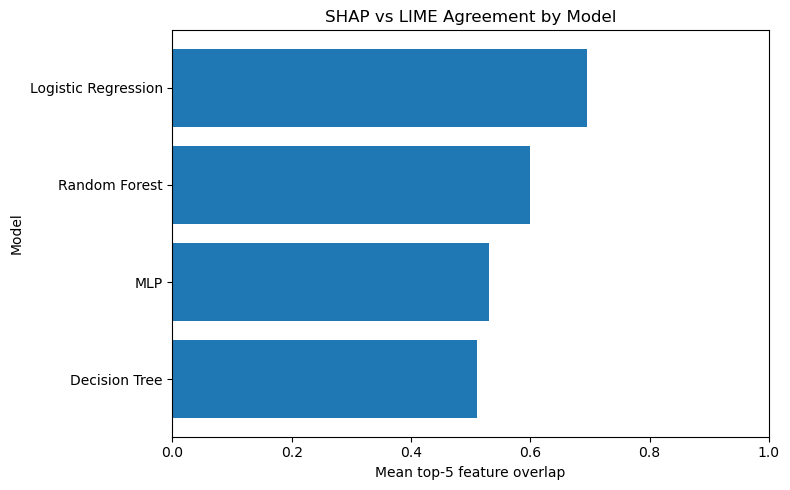

Saved plot: /home/iailab42/khans1/projects/xai/plots/07_explanation_stability/shap_lime_agreement_by_model.png


In [10]:
plot_df = method_agreement_summary_by_model.copy()
plot_df = plot_df.sort_values(by="mean_top_k_overlap", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(plot_df["display_name"], plot_df["mean_top_k_overlap"])
plt.xlabel(f"Mean top-{TOP_K} feature overlap")
plt.ylabel("Model")
plt.title("SHAP vs LIME Agreement by Model")
plt.xlim(0, 1)
plt.tight_layout()

plot_path = PLOTS_DIR / "shap_lime_agreement_by_model.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved plot: {plot_path}")

### Cell 9 — Cross-Model Explanation Stability

In [11]:
cross_model_rows = []

model_pairs = list(itertools.combinations(MODEL_ORDER, 2))

for method in METHOD_NAMES:
    for sample_id in sample_ids:
        sample_info = selected_samples[
            selected_samples["sample_id"] == sample_id
        ].iloc[0]

        for model_a, model_b in model_pairs:

            explanation_a = get_explanation_subset(
                explanation_df=unified_explanations,
                method=method,
                model_name=model_a,
                sample_id=sample_id
            )

            explanation_b = get_explanation_subset(
                explanation_df=unified_explanations,
                method=method,
                model_name=model_b,
                sample_id=sample_id
            )

            if explanation_a.empty or explanation_b.empty:
                continue

            metrics = compare_two_explanations(
                explanation_a=explanation_a,
                explanation_b=explanation_b,
                all_features=feature_columns,
                k=TOP_K
            )

            cross_model_rows.append({
                "comparison_type": "cross_model_same_method",
                "method": method,
                "model_a": model_a,
                "model_b": model_b,
                "model_pair": f"{MODEL_DISPLAY_NAMES[model_a]} vs {MODEL_DISPLAY_NAMES[model_b]}",
                "sample_id": sample_id,
                "row_index": int(sample_info["row_index"]),
                "selection_group": sample_info["selection_group"],
                "true_label": int(sample_info["true_label"]),
                "true_class_name": sample_info["true_class_name"],
                **metrics
            })

cross_model_df = pd.DataFrame(cross_model_rows)

cross_model_path = RESULTS_DIR / "cross_model_stability_by_sample.csv"
cross_model_df.to_csv(cross_model_path, index=False)

cross_model_summary = (
    cross_model_df
    .groupby(["method", "model_pair"], as_index=False)
    .agg(
        mean_top_k_overlap=("top_k_overlap", "mean"),
        mean_jaccard_similarity=("jaccard_similarity", "mean"),
        mean_rank_correlation=("rank_correlation", "mean"),
        mean_signed_cosine_similarity=("signed_cosine_similarity", "mean"),
        mean_abs_cosine_similarity=("abs_cosine_similarity", "mean"),
        n_comparisons=("sample_id", "count")
    )
)

cross_model_summary_path = RESULTS_DIR / "cross_model_stability_summary.csv"
cross_model_summary.to_csv(cross_model_summary_path, index=False)

print(f"Saved cross-model stability by sample: {cross_model_path}")
print(f"Saved cross-model stability summary: {cross_model_summary_path}")

display(cross_model_summary)

Saved cross-model stability by sample: /home/iailab42/khans1/projects/xai/results/07_explanation_stability/cross_model_stability_by_sample.csv
Saved cross-model stability summary: /home/iailab42/khans1/projects/xai/results/07_explanation_stability/cross_model_stability_summary.csv


,method,model_pair,mean_top_k_overlap,mean_jaccard_similarity,mean_rank_correlation,mean_signed_cosine_similarity,mean_abs_cosine_similarity,n_comparisons
0,LIME,Decision Tree vs MLP,0.395,0.262103,-0.506787,0.194691,0.297627,40
1,LIME,Decision Tree vs Random Forest,0.460,0.317460,-0.076420,0.466117,0.549183,40
2,LIME,Logistic Regression vs Decision Tree,0.410,0.280159,-0.409232,0.283351,0.347956,40
3,LIME,Logistic Regression vs MLP,0.685,0.544544,0.236006,0.720224,0.762947,40
4,LIME,Logistic Regression vs Random Forest,0.475,0.341468,-0.276617,0.413744,0.420691,40
5,LIME,Random Forest vs MLP,0.430,0.293353,-0.450074,0.339351,0.376975,40
6,SHAP,Decision Tree vs MLP,0.450,0.302579,-0.409302,0.313133,0.347857,40
7,SHAP,Decision Tree vs Random Forest,0.510,0.363294,-0.191349,0.510905,0.526390,40
8,SHAP,Logistic Regression vs Decision Tree,0.485,0.347917,-0.261162,0.415290,0.449396,40
9,SHAP,Logistic Regression vs MLP,0.410,0.275496,-0.311349,0.417386,0.427624,40


### Cell 10 — Plot Cross-Model Stability

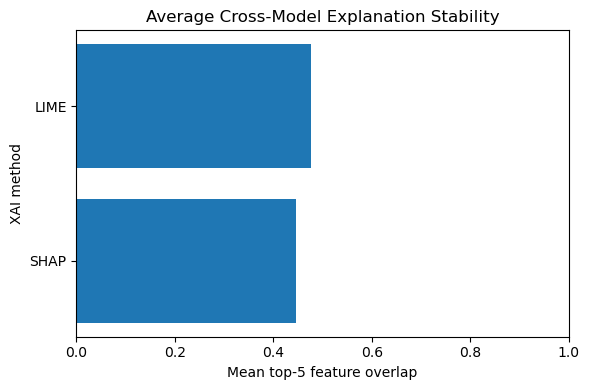

Saved plot: /home/iailab42/khans1/projects/xai/plots/07_explanation_stability/cross_model_stability_by_method.png


In [12]:
plot_df = (
    cross_model_df
    .groupby("method", as_index=False)
    .agg(mean_top_k_overlap=("top_k_overlap", "mean"))
)

plot_df = plot_df.sort_values(by="mean_top_k_overlap", ascending=True)

plt.figure(figsize=(6, 4))
plt.barh(plot_df["method"], plot_df["mean_top_k_overlap"])
plt.xlabel(f"Mean top-{TOP_K} feature overlap")
plt.ylabel("XAI method")
plt.title("Average Cross-Model Explanation Stability")
plt.xlim(0, 1)
plt.tight_layout()

plot_path = PLOTS_DIR / "cross_model_stability_by_method.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved plot: {plot_path}")

### Cell 11 — Within-Group Explanation Stability

In [13]:
within_group_rows = []

for method in METHOD_NAMES:
    for model_name in MODEL_ORDER:
        for selection_group, group_df in selected_samples.groupby("selection_group"):

            group_sample_ids = group_df["sample_id"].tolist()

            if len(group_sample_ids) < 2:
                continue

            for sample_a, sample_b in itertools.combinations(group_sample_ids, 2):

                explanation_a = get_explanation_subset(
                    explanation_df=unified_explanations,
                    method=method,
                    model_name=model_name,
                    sample_id=sample_a
                )

                explanation_b = get_explanation_subset(
                    explanation_df=unified_explanations,
                    method=method,
                    model_name=model_name,
                    sample_id=sample_b
                )

                if explanation_a.empty or explanation_b.empty:
                    continue

                metrics = compare_two_explanations(
                    explanation_a=explanation_a,
                    explanation_b=explanation_b,
                    all_features=feature_columns,
                    k=TOP_K
                )

                sample_a_info = selected_samples[
                    selected_samples["sample_id"] == sample_a
                ].iloc[0]

                sample_b_info = selected_samples[
                    selected_samples["sample_id"] == sample_b
                ].iloc[0]

                within_group_rows.append({
                    "comparison_type": "within_selection_group",
                    "method": method,
                    "model_name": model_name,
                    "display_name": MODEL_DISPLAY_NAMES[model_name],
                    "selection_group": selection_group,
                    "sample_id_a": sample_a,
                    "sample_id_b": sample_b,
                    "row_index_a": int(sample_a_info["row_index"]),
                    "row_index_b": int(sample_b_info["row_index"]),
                    "true_class_name_a": sample_a_info["true_class_name"],
                    "true_class_name_b": sample_b_info["true_class_name"],
                    **metrics
                })

within_group_df = pd.DataFrame(within_group_rows)

within_group_path = RESULTS_DIR / "within_group_stability_pairs.csv"
within_group_df.to_csv(within_group_path, index=False)

within_group_summary = (
    within_group_df
    .groupby(["method", "model_name", "display_name", "selection_group"], as_index=False)
    .agg(
        mean_top_k_overlap=("top_k_overlap", "mean"),
        mean_jaccard_similarity=("jaccard_similarity", "mean"),
        mean_rank_correlation=("rank_correlation", "mean"),
        mean_signed_cosine_similarity=("signed_cosine_similarity", "mean"),
        mean_abs_cosine_similarity=("abs_cosine_similarity", "mean"),
        n_pairs=("sample_id_a", "count")
    )
)

within_group_summary_path = RESULTS_DIR / "within_group_stability_summary.csv"
within_group_summary.to_csv(within_group_summary_path, index=False)

print(f"Saved within-group stability pairs: {within_group_path}")
print(f"Saved within-group stability summary: {within_group_summary_path}")

display(within_group_summary.head(20))

Saved within-group stability pairs: /home/iailab42/khans1/projects/xai/results/07_explanation_stability/within_group_stability_pairs.csv
Saved within-group stability summary: /home/iailab42/khans1/projects/xai/results/07_explanation_stability/within_group_stability_summary.csv


,method,model_name,display_name,selection_group,mean_top_k_overlap,mean_jaccard_similarity,mean_rank_correlation,mean_signed_cosine_similarity,mean_abs_cosine_similarity,n_pairs
0,LIME,decision_tree,Decision Tree,barbunya_predicted_as_cali,0.640000,0.502381,0.220844,0.667457,0.756463,15
1,LIME,decision_tree,Decision Tree,correct_bombay,0.600000,0.428571,0.563636,0.919245,0.919245,1
2,LIME,decision_tree,Decision Tree,correct_dermason,0.685714,0.536139,0.620153,0.899228,0.906195,28
3,LIME,decision_tree,Decision Tree,correct_sira,0.438095,0.294407,-0.342053,0.244111,0.410483,21
4,LIME,decision_tree,Decision Tree,dermason_predicted_as_sira,0.426667,0.285714,-0.011118,0.500249,0.617321,45
5,LIME,decision_tree,Decision Tree,sira_predicted_as_dermason,0.571429,0.411565,0.173006,0.511824,0.669447,21
6,LIME,logistic_regression,Logistic Regression,barbunya_predicted_as_cali,0.706667,0.559524,0.541948,0.863988,0.863988,15
7,LIME,logistic_regression,Logistic Regression,correct_bombay,0.800000,0.666667,0.885714,0.940098,0.940098,1
8,LIME,logistic_regression,Logistic Regression,correct_dermason,0.771429,0.655187,0.198145,0.716386,0.716386,28
9,LIME,logistic_regression,Logistic Regression,correct_sira,0.466667,0.323129,-0.008599,0.508498,0.598738,21


### Cell 12 — Plot Within-Group Stability

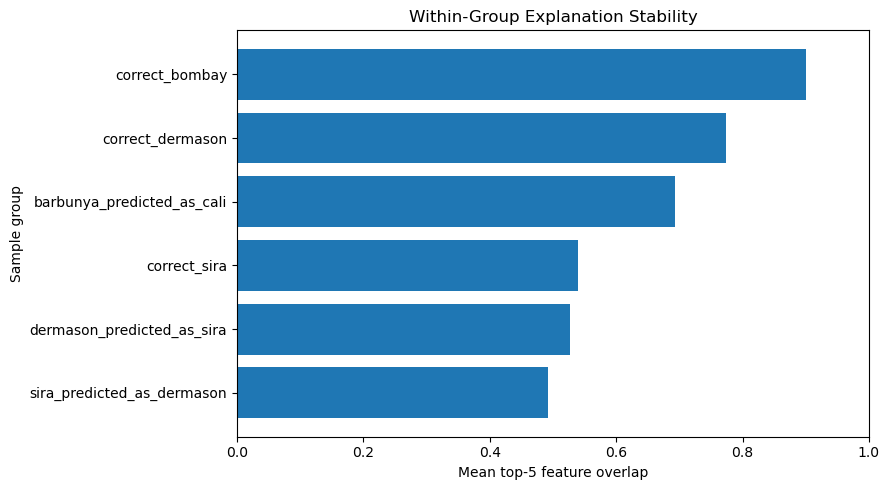

Saved plot: /home/iailab42/khans1/projects/xai/plots/07_explanation_stability/within_group_stability_by_selection_group.png


In [14]:
plot_df = (
    within_group_df
    .groupby("selection_group", as_index=False)
    .agg(mean_top_k_overlap=("top_k_overlap", "mean"))
)

plot_df = plot_df.sort_values(by="mean_top_k_overlap", ascending=True)

plt.figure(figsize=(9, 5))
plt.barh(plot_df["selection_group"], plot_df["mean_top_k_overlap"])
plt.xlabel(f"Mean top-{TOP_K} feature overlap")
plt.ylabel("Sample group")
plt.title("Within-Group Explanation Stability")
plt.xlim(0, 1)
plt.tight_layout()

plot_path = PLOTS_DIR / "within_group_stability_by_selection_group.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved plot: {plot_path}")

### Cell 13 — Build Nearest-Neighbor Pairs from Feature Space

In [15]:
selected_samples_sorted = selected_samples.sort_values(by="sample_id").reset_index(drop=True)
selected_row_indices = selected_samples_sorted["row_index"].astype(int).tolist()

selected_feature_matrix = X_test_scaled.iloc[selected_row_indices].reset_index(drop=True)

distance_matrix = pairwise_distances(
    selected_feature_matrix,
    metric="euclidean"
)

np.fill_diagonal(distance_matrix, np.inf)

nearest_neighbor_rows = []

for sample_position, sample_row in selected_samples_sorted.iterrows():
    nearest_position = int(np.argmin(distance_matrix[sample_position]))
    nearest_row = selected_samples_sorted.iloc[nearest_position]

    nearest_neighbor_rows.append({
        "sample_id": sample_row["sample_id"],
        "nearest_sample_id": nearest_row["sample_id"],
        "row_index": int(sample_row["row_index"]),
        "nearest_row_index": int(nearest_row["row_index"]),
        "selection_group": sample_row["selection_group"],
        "nearest_selection_group": nearest_row["selection_group"],
        "true_class_name": sample_row["true_class_name"],
        "nearest_true_class_name": nearest_row["true_class_name"],
        "feature_distance": float(distance_matrix[sample_position, nearest_position]),
        "same_selection_group": sample_row["selection_group"] == nearest_row["selection_group"],
        "same_true_class": sample_row["true_class_name"] == nearest_row["true_class_name"]
    })

nearest_neighbor_df = pd.DataFrame(nearest_neighbor_rows)

nearest_neighbor_path = RESULTS_DIR / "nearest_neighbor_pairs.csv"
nearest_neighbor_df.to_csv(nearest_neighbor_path, index=False)

print(f"Saved nearest-neighbor pairs: {nearest_neighbor_path}")
display(nearest_neighbor_df.head(20))

Saved nearest-neighbor pairs: /home/iailab42/khans1/projects/xai/results/07_explanation_stability/nearest_neighbor_pairs.csv


,sample_id,nearest_sample_id,row_index,nearest_row_index,selection_group,nearest_selection_group,true_class_name,nearest_true_class_name,feature_distance,same_selection_group,same_true_class
0,2573,2790,192,126,barbunya_predicted_as_cali,barbunya_predicted_as_cali,BARBUNYA,BARBUNYA,1.068148,True,True
1,2590,2790,960,126,barbunya_predicted_as_cali,barbunya_predicted_as_cali,BARBUNYA,BARBUNYA,2.035253,True,True
2,2591,2883,66,553,barbunya_predicted_as_cali,barbunya_predicted_as_cali,BARBUNYA,BARBUNYA,2.991705,True,True
3,2790,2573,126,192,barbunya_predicted_as_cali,barbunya_predicted_as_cali,BARBUNYA,BARBUNYA,1.068148,True,True
4,2883,2790,553,126,barbunya_predicted_as_cali,barbunya_predicted_as_cali,BARBUNYA,BARBUNYA,1.530947,True,True
5,3330,2883,895,553,barbunya_predicted_as_cali,barbunya_predicted_as_cali,BARBUNYA,BARBUNYA,2.317125,True,True
6,3450,3330,1567,895,correct_bombay,barbunya_predicted_as_cali,BOMBAY,BARBUNYA,5.205782,False,False
7,3869,3450,806,1567,correct_bombay,correct_bombay,BOMBAY,BOMBAY,7.570171,True,True
8,7426,12838,942,2412,sira_predicted_as_dermason,correct_dermason,SIRA,DERMASON,0.867631,False,False
9,7434,7683,693,2179,sira_predicted_as_dermason,sira_predicted_as_dermason,SIRA,SIRA,0.774555,True,True


### Cell 14 — Nearest-Neighbor Explanation Stability

In [16]:
nearest_stability_rows = []

for _, pair_row in nearest_neighbor_df.iterrows():
    sample_id = pair_row["sample_id"]
    nearest_sample_id = pair_row["nearest_sample_id"]

    for method in METHOD_NAMES:
        for model_name in MODEL_ORDER:

            explanation_a = get_explanation_subset(
                explanation_df=unified_explanations,
                method=method,
                model_name=model_name,
                sample_id=sample_id
            )

            explanation_b = get_explanation_subset(
                explanation_df=unified_explanations,
                method=method,
                model_name=model_name,
                sample_id=nearest_sample_id
            )

            if explanation_a.empty or explanation_b.empty:
                continue

            metrics = compare_two_explanations(
                explanation_a=explanation_a,
                explanation_b=explanation_b,
                all_features=feature_columns,
                k=TOP_K
            )

            nearest_stability_rows.append({
                "comparison_type": "nearest_neighbor_explanation_stability",
                "method": method,
                "model_name": model_name,
                "display_name": MODEL_DISPLAY_NAMES[model_name],
                "sample_id": sample_id,
                "nearest_sample_id": nearest_sample_id,
                "selection_group": pair_row["selection_group"],
                "nearest_selection_group": pair_row["nearest_selection_group"],
                "true_class_name": pair_row["true_class_name"],
                "nearest_true_class_name": pair_row["nearest_true_class_name"],
                "feature_distance": pair_row["feature_distance"],
                "same_selection_group": pair_row["same_selection_group"],
                "same_true_class": pair_row["same_true_class"],
                **metrics
            })

nearest_stability_df = pd.DataFrame(nearest_stability_rows)

nearest_stability_path = RESULTS_DIR / "nearest_neighbor_explanation_stability.csv"
nearest_stability_df.to_csv(nearest_stability_path, index=False)

nearest_stability_summary = (
    nearest_stability_df
    .groupby(["method", "model_name", "display_name"], as_index=False)
    .agg(
        mean_feature_distance=("feature_distance", "mean"),
        mean_top_k_overlap=("top_k_overlap", "mean"),
        mean_jaccard_similarity=("jaccard_similarity", "mean"),
        mean_rank_correlation=("rank_correlation", "mean"),
        mean_signed_cosine_similarity=("signed_cosine_similarity", "mean"),
        mean_abs_cosine_similarity=("abs_cosine_similarity", "mean"),
        n_pairs=("sample_id", "count")
    )
)

nearest_stability_summary_path = RESULTS_DIR / "nearest_neighbor_stability_summary.csv"
nearest_stability_summary.to_csv(nearest_stability_summary_path, index=False)

print(f"Saved nearest-neighbor explanation stability: {nearest_stability_path}")
print(f"Saved nearest-neighbor stability summary: {nearest_stability_summary_path}")

display(nearest_stability_summary)

Saved nearest-neighbor explanation stability: /home/iailab42/khans1/projects/xai/results/07_explanation_stability/nearest_neighbor_explanation_stability.csv
Saved nearest-neighbor stability summary: /home/iailab42/khans1/projects/xai/results/07_explanation_stability/nearest_neighbor_stability_summary.csv


,method,model_name,display_name,mean_feature_distance,mean_top_k_overlap,mean_jaccard_similarity,mean_rank_correlation,mean_signed_cosine_similarity,mean_abs_cosine_similarity,n_pairs
0,LIME,decision_tree,Decision Tree,1.324019,0.505,0.357937,0.115869,0.524233,0.660994,40
1,LIME,logistic_regression,Logistic Regression,1.324019,0.590,0.454563,0.019083,0.608507,0.608507,40
2,LIME,mlp,MLP,1.324019,0.605,0.486607,0.122060,0.593951,0.607205,40
3,LIME,random_forest,Random Forest,1.324019,0.730,0.612401,0.212086,0.725855,0.745832,40
4,SHAP,decision_tree,Decision Tree,1.324019,0.595,0.466171,0.038904,0.514258,0.591864,40
5,SHAP,logistic_regression,Logistic Regression,1.324019,0.775,0.688790,0.371437,0.708517,0.800859,40
6,SHAP,mlp,MLP,1.324019,0.595,0.443651,0.099292,0.618676,0.636084,40
7,SHAP,random_forest,Random Forest,1.324019,0.640,0.502381,0.058977,0.581741,0.625575,40


### Cell 15 — Plot Nearest-Neighbor Stability

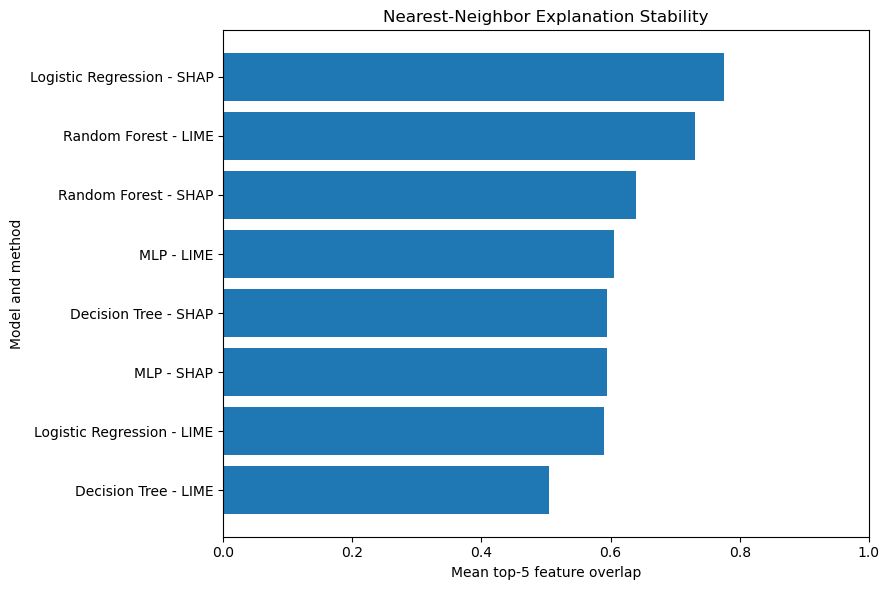

Saved plot: /home/iailab42/khans1/projects/xai/plots/07_explanation_stability/nearest_neighbor_stability_by_model_method.png


In [17]:
nearest_stability_summary["model_method"] = (
    nearest_stability_summary["display_name"]
    + " - "
    + nearest_stability_summary["method"]
)

plot_df = nearest_stability_summary.sort_values(
    by="mean_top_k_overlap",
    ascending=True
)

plt.figure(figsize=(9, 6))
plt.barh(plot_df["model_method"], plot_df["mean_top_k_overlap"])
plt.xlabel(f"Mean top-{TOP_K} feature overlap")
plt.ylabel("Model and method")
plt.title("Nearest-Neighbor Explanation Stability")
plt.xlim(0, 1)
plt.tight_layout()

plot_path = PLOTS_DIR / "nearest_neighbor_stability_by_model_method.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved plot: {plot_path}")

### Cell 16 — DERMASON/SIRA Focused Stability Analysis

In [18]:
dermason_sira_groups = [
    "correct_dermason",
    "correct_sira",
    "dermason_predicted_as_sira",
    "sira_predicted_as_dermason"
]

dermason_sira_method_agreement = method_agreement_df[
    method_agreement_df["selection_group"].isin(dermason_sira_groups)
].copy()

dermason_sira_within_group = within_group_df[
    within_group_df["selection_group"].isin(dermason_sira_groups)
].copy()

dermason_sira_nearest = nearest_stability_df[
    nearest_stability_df["selection_group"].isin(dermason_sira_groups)
].copy()

dermason_sira_summary = {
    "method_agreement": {
        "mean_top_k_overlap": safe_mean(dermason_sira_method_agreement["top_k_overlap"]),
        "mean_abs_cosine_similarity": safe_mean(dermason_sira_method_agreement["abs_cosine_similarity"]),
        "n_comparisons": int(len(dermason_sira_method_agreement))
    },
    "within_group_stability": {
        "mean_top_k_overlap": safe_mean(dermason_sira_within_group["top_k_overlap"]),
        "mean_abs_cosine_similarity": safe_mean(dermason_sira_within_group["abs_cosine_similarity"]),
        "n_pairs": int(len(dermason_sira_within_group))
    },
    "nearest_neighbor_stability": {
        "mean_top_k_overlap": safe_mean(dermason_sira_nearest["top_k_overlap"]),
        "mean_abs_cosine_similarity": safe_mean(dermason_sira_nearest["abs_cosine_similarity"]),
        "n_pairs": int(len(dermason_sira_nearest))
    }
}

dermason_sira_summary_path = RESULTS_DIR / "dermason_sira_stability_summary.json"
save_json(dermason_sira_summary, dermason_sira_summary_path)

print(f"Saved DERMASON/SIRA stability summary: {dermason_sira_summary_path}")
print(json.dumps(dermason_sira_summary, indent=4))

Saved DERMASON/SIRA stability summary: /home/iailab42/khans1/projects/xai/results/07_explanation_stability/dermason_sira_stability_summary.json
{
    "method_agreement": {
        "mean_top_k_overlap": 0.5609374999999999,
        "mean_abs_cosine_similarity": 0.5900522845815741,
        "n_comparisons": 128
    },
    "within_group_stability": {
        "mean_top_k_overlap": 0.5830434782608696,
        "mean_abs_cosine_similarity": 0.609693094706264,
        "n_pairs": 920
    },
    "nearest_neighbor_stability": {
        "mean_top_k_overlap": 0.60703125,
        "mean_abs_cosine_similarity": 0.6374298964664459,
        "n_pairs": 256
    }
}


### Cell 17 — Create Overall Stability Summary Table

In [19]:
overall_summary_rows = []

overall_summary_rows.append({
    "analysis": "SHAP vs LIME method agreement",
    "mean_top_k_overlap": safe_mean(method_agreement_df["top_k_overlap"]),
    "std_top_k_overlap": safe_std(method_agreement_df["top_k_overlap"]),
    "mean_jaccard_similarity": safe_mean(method_agreement_df["jaccard_similarity"]),
    "mean_rank_correlation": safe_mean(method_agreement_df["rank_correlation"]),
    "mean_abs_cosine_similarity": safe_mean(method_agreement_df["abs_cosine_similarity"]),
    "n_comparisons": int(len(method_agreement_df))
})

overall_summary_rows.append({
    "analysis": "Cross-model stability",
    "mean_top_k_overlap": safe_mean(cross_model_df["top_k_overlap"]),
    "std_top_k_overlap": safe_std(cross_model_df["top_k_overlap"]),
    "mean_jaccard_similarity": safe_mean(cross_model_df["jaccard_similarity"]),
    "mean_rank_correlation": safe_mean(cross_model_df["rank_correlation"]),
    "mean_abs_cosine_similarity": safe_mean(cross_model_df["abs_cosine_similarity"]),
    "n_comparisons": int(len(cross_model_df))
})

overall_summary_rows.append({
    "analysis": "Within-group stability",
    "mean_top_k_overlap": safe_mean(within_group_df["top_k_overlap"]),
    "std_top_k_overlap": safe_std(within_group_df["top_k_overlap"]),
    "mean_jaccard_similarity": safe_mean(within_group_df["jaccard_similarity"]),
    "mean_rank_correlation": safe_mean(within_group_df["rank_correlation"]),
    "mean_abs_cosine_similarity": safe_mean(within_group_df["abs_cosine_similarity"]),
    "n_comparisons": int(len(within_group_df))
})

overall_summary_rows.append({
    "analysis": "Nearest-neighbor stability",
    "mean_top_k_overlap": safe_mean(nearest_stability_df["top_k_overlap"]),
    "std_top_k_overlap": safe_std(nearest_stability_df["top_k_overlap"]),
    "mean_jaccard_similarity": safe_mean(nearest_stability_df["jaccard_similarity"]),
    "mean_rank_correlation": safe_mean(nearest_stability_df["rank_correlation"]),
    "mean_abs_cosine_similarity": safe_mean(nearest_stability_df["abs_cosine_similarity"]),
    "n_comparisons": int(len(nearest_stability_df))
})

overall_stability_summary = pd.DataFrame(overall_summary_rows)

overall_summary_path = RESULTS_DIR / "overall_stability_summary.csv"
overall_stability_summary.to_csv(overall_summary_path, index=False)

print(f"Saved overall stability summary: {overall_summary_path}")
display(overall_stability_summary)

Saved overall stability summary: /home/iailab42/khans1/projects/xai/results/07_explanation_stability/overall_stability_summary.csv


,analysis,mean_top_k_overlap,std_top_k_overlap,mean_jaccard_similarity,mean_rank_correlation,mean_abs_cosine_similarity,n_comparisons
0,SHAP vs LIME method agreement,0.583750,0.228720,0.449206,0.048828,0.612342,160
1,Cross-model stability,0.460833,0.211879,0.325141,-0.287796,0.443638,480
2,Within-group stability,0.598092,0.232745,0.467694,0.073991,0.626914,1048
3,Nearest-neighbor stability,0.629375,0.228419,0.501563,0.129714,0.659615,320


### Cell 18 — Save Notebook Summary JSON

In [20]:
notebook_summary = {
    "notebook": NOTEBOOK_NAME,
    "random_state": RANDOM_STATE,
    "top_k": TOP_K,
    "models": MODEL_ORDER,
    "methods": METHOD_NAMES,
    "number_of_selected_samples": int(len(selected_samples)),
    "input_files": {
        "selected_samples": "results/05_shap_explanations/selected_samples.csv",
        "local_shap": "results/05_shap_explanations/local_shap_explanations_all_models.csv",
        "local_lime_top_k": f"results/06_lime_explanations/local_lime_top_{TOP_K}_explanations_all_models.csv",
        "local_lime_full": "results/06_lime_explanations/local_lime_explanations_all_models.csv",
        "X_test_scaled": "data/processed/X_test_scaled.csv"
    },
    "saved_outputs": {
        "unified_top_k_explanations": "results/07_explanation_stability/unified_top_k_explanations.csv",
        "shap_lime_method_agreement_by_sample": "results/07_explanation_stability/shap_lime_method_agreement_by_sample.csv",
        "shap_lime_method_agreement_summary_by_model": "results/07_explanation_stability/shap_lime_method_agreement_summary_by_model.csv",
        "cross_model_stability_by_sample": "results/07_explanation_stability/cross_model_stability_by_sample.csv",
        "cross_model_stability_summary": "results/07_explanation_stability/cross_model_stability_summary.csv",
        "within_group_stability_pairs": "results/07_explanation_stability/within_group_stability_pairs.csv",
        "within_group_stability_summary": "results/07_explanation_stability/within_group_stability_summary.csv",
        "nearest_neighbor_pairs": "results/07_explanation_stability/nearest_neighbor_pairs.csv",
        "nearest_neighbor_explanation_stability": "results/07_explanation_stability/nearest_neighbor_explanation_stability.csv",
        "nearest_neighbor_stability_summary": "results/07_explanation_stability/nearest_neighbor_stability_summary.csv",
        "dermason_sira_stability_summary": "results/07_explanation_stability/dermason_sira_stability_summary.json",
        "overall_stability_summary": "results/07_explanation_stability/overall_stability_summary.csv"
    },
    "plots": {
        "shap_lime_agreement_by_model": "plots/07_explanation_stability/shap_lime_agreement_by_model.png",
        "cross_model_stability_by_method": "plots/07_explanation_stability/cross_model_stability_by_method.png",
        "within_group_stability_by_selection_group": "plots/07_explanation_stability/within_group_stability_by_selection_group.png",
        "nearest_neighbor_stability_by_model_method": "plots/07_explanation_stability/nearest_neighbor_stability_by_model_method.png"
    }
}

summary_path = RESULTS_DIR / "explanation_stability_summary.json"
save_json(notebook_summary, summary_path)

print(f"Saved notebook summary: {summary_path}")

Saved notebook summary: /home/iailab42/khans1/projects/xai/results/07_explanation_stability/explanation_stability_summary.json


In [21]:
print("Notebook 07 completed.")

print("\nSaved result files:")
for path in sorted(RESULTS_DIR.glob("*")):
    print(path.name)

print("\nSaved plot files:")
for path in sorted(PLOTS_DIR.glob("*")):
    print(path.name)

Notebook 07 completed.

Saved result files:
cross_model_stability_by_sample.csv
cross_model_stability_summary.csv
dermason_sira_stability_summary.json
explanation_stability_summary.json
nearest_neighbor_explanation_stability.csv
nearest_neighbor_pairs.csv
nearest_neighbor_stability_summary.csv
overall_stability_summary.csv
shap_lime_method_agreement_by_sample.csv
shap_lime_method_agreement_summary_by_model.csv
unified_top_k_explanations.csv
within_group_stability_pairs.csv
within_group_stability_summary.csv

Saved plot files:
cross_model_stability_by_method.png
nearest_neighbor_stability_by_model_method.png
shap_lime_agreement_by_model.png
within_group_stability_by_selection_group.png
